# Wavelet transform example notebook

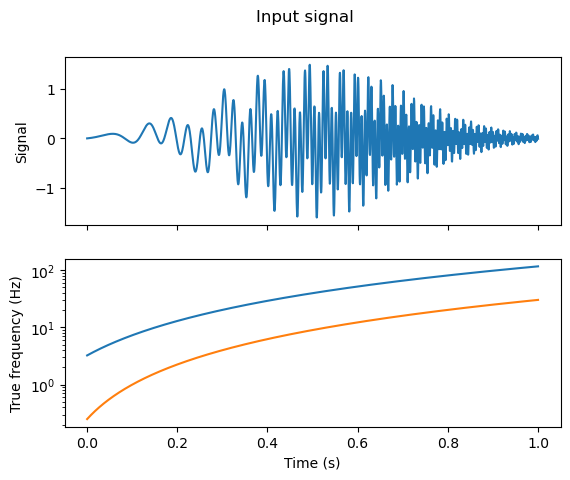

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pywt


def gaussian(x, x0, sigma):
    return np.exp(-np.power((x - x0) / sigma, 2.0) / 2.0)


def make_chirp(t, t0, a):
    frequency = (a * (t + t0)) ** 2
    chirp = np.sin(2 * np.pi * frequency * t)
    return chirp, frequency


# generate signal
time = np.linspace(0, 1, 2000)
chirp1, frequency1 = make_chirp(time, 0.2, 9)
chirp2, frequency2 = make_chirp(time, 0.1, 5)
chirp = chirp1 + 0.6 * chirp2
chirp *= gaussian(time, 0.5, 0.2)

# plot signal
fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].plot(time, chirp)
axs[1].plot(time, frequency1)
axs[1].plot(time, frequency2)
axs[1].set_yscale("log")
axs[1].set_xlabel("Time (s)")
axs[0].set_ylabel("Signal")
axs[1].set_ylabel("True frequency (Hz)")
plt.suptitle("Input signal")
plt.show()

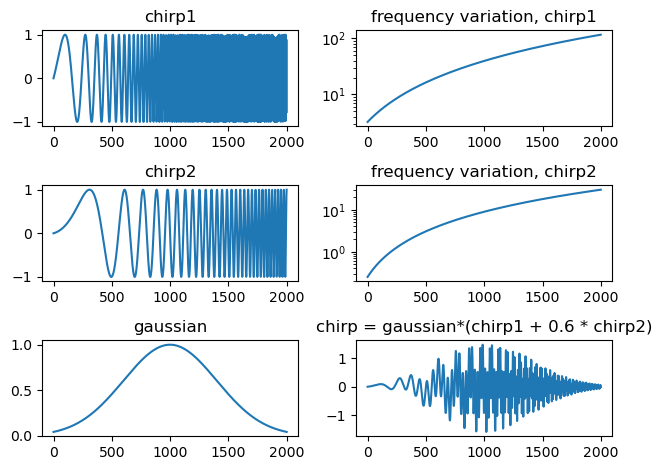

In [22]:
plt.figure()
plt.subplot(3,2,1)
plt.plot(chirp1)
plt.title('chirp1')
plt.subplot(3,2,2)
plt.plot(frequency1)
plt.title('frequency variation, chirp1')
plt.yscale('log')

plt.subplot(3,2,3)
plt.plot(chirp2)
plt.title('chirp2')
plt.subplot(3,2,4)
plt.plot(frequency2)
plt.title('frequency variation, chirp2')
plt.yscale('log')

plt.subplot(3,2,5)
gaussian_ = gaussian(time, 0.5, 0.2)
plt.plot(gaussian_)
plt.title('gaussian')
plt.subplot(3,2,6)
plt.plot(chirp)
plt.title('chirp = gaussian*(chirp1 + 0.6 * chirp2)')


plt.tight_layout()
plt.show()

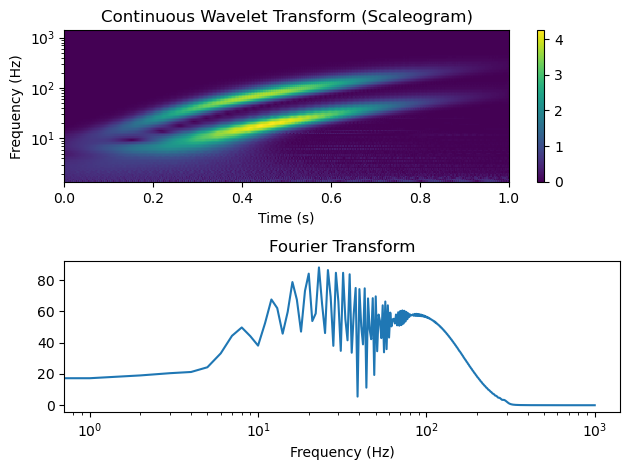

In [50]:
# perform CWT
wavelet = "cmor1.5-1.0"
wavelet = "cgau8"
# logarithmic scale for scales, as suggested by Torrence & Compo:
widths = np.geomspace(1, 1024, num=100) # Return numbers spaced evenly on a log scale (a geometric progression).
sampling_period = np.diff(time).mean()
cwtmatr, freqs = pywt.cwt(chirp, widths, wavelet, sampling_period=sampling_period)
# absolute take absolute value of complex result
cwtmatr = np.abs(cwtmatr[:-1, :-1])

# plot result using matplotlib's pcolormesh (image with annoted axes)
fig, axs = plt.subplots(2, 1)
pcm = axs[0].pcolormesh(time, freqs, cwtmatr)
axs[0].set_yscale("log")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Frequency (Hz)")
axs[0].set_title("Continuous Wavelet Transform (Scaleogram)")
fig.colorbar(pcm, ax=axs[0])

# plot fourier transform for comparison
from numpy.fft import rfft, rfftfreq

yf = rfft(chirp)
xf = rfftfreq(len(chirp), sampling_period)
plt.semilogx(xf, np.abs(yf))
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_title("Fourier Transform")
plt.tight_layout()

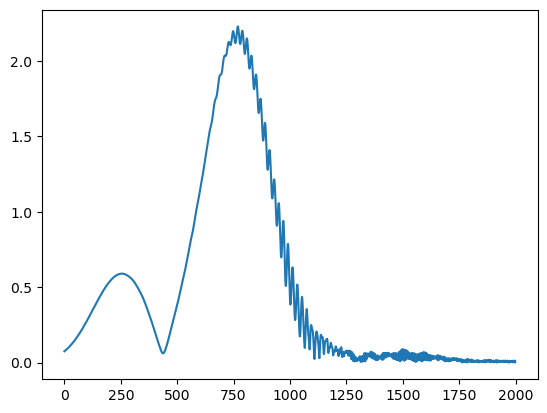

In [38]:
plt.plot(cwtmatr[70,:])

The Continuous Wavelet Transform can resolve the two frequency components clearly, which is an obvious advantage over the Fourier Transform in this case. The scales (widths) are given on a logarithmic scale in the example. The scales determine the frequency resolution of the scaleogram. However, it is not straightforward to convert them to frequencies, but luckily, cwt calculates the correct frequencies for us. There are also helper functions, that perform this conversion in both ways. For more information, see Choosing the scales for cwt and Converting frequency to scale for cwt.

Also note, that the raw output of cwt is complex if a complex wavelet is used. For visualization, it is therefore necessary to use the absolute value.

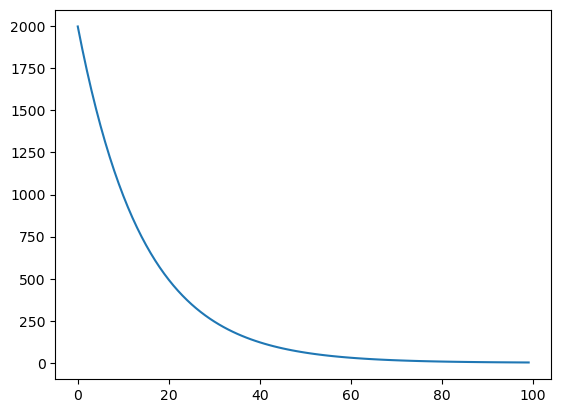

In [32]:
plt.plot(freqs)

C:\Users\OWNER\AppData\Local\Temp\ipykernel_26052\3732882424.py:45: RuntimeWarning: invalid value encountered in log10
  plt.plot(time[:-1], np.log10(instantaneous_frequency[1]), label="Instantaneous Frequency (IMF 2)")


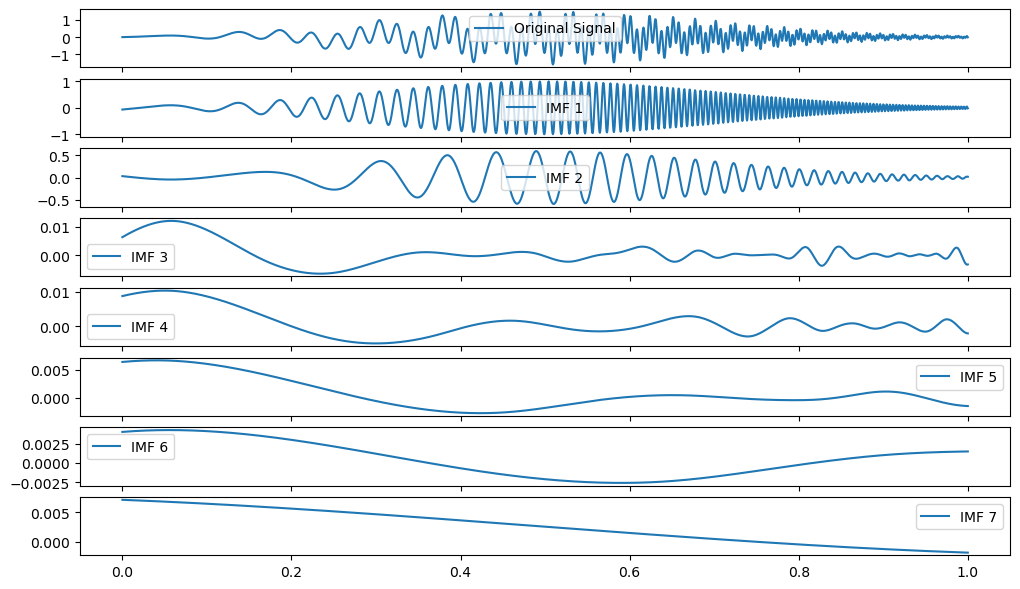

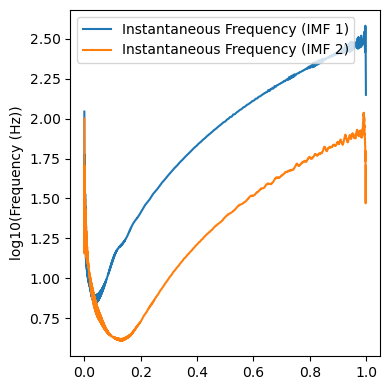

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD
from scipy.signal import hilbert

# Define the signal
def gaussian(x, x0, sigma):
    return np.exp(-np.power((x - x0) / sigma, 2.0) / 2.0)

def make_chirp(t, t0, a):
    frequency = (a * (t + t0)) ** 2
    chirp = np.sin(2 * np.pi * frequency * t)
    return chirp, frequency

# Generate signal
time = np.linspace(0, 1, 2000)
chirp1, frequency1 = make_chirp(time, 0.2, 9)
chirp2, frequency2 = make_chirp(time, 0.1, 5)
chirp = chirp1 + 0.6 * chirp2
chirp *= gaussian(time, 0.5, 0.2)

# Perform Empirical Mode Decomposition (EMD)
emd = EMD()
imfs = emd.emd(chirp, time)

# Plot IMFs
plt.figure(figsize=(12, 8))
plt.subplot(len(imfs) + 2, 1, 1)
plt.plot(time, chirp, label="Original Signal")
plt.legend()
for i, imf in enumerate(imfs):
    plt.subplot(len(imfs) + 2, 1, i + 2)
    plt.plot(time, imf, label=f"IMF {i+1}")
    plt.legend()

# Apply Hilbert transform to the IMFs
analytic_signal = hilbert(imfs)
amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
instantaneous_frequency = np.diff(instantaneous_phase, axis=1) / (2.0 * np.pi * np.diff(time))

# Plot amplitude and frequency for first IMF
plt.figure(figsize=(4,4))
plt.plot(time[:-1], np.log10(instantaneous_frequency[0]), label="Instantaneous Frequency (IMF 1)")
plt.plot(time[:-1], np.log10(instantaneous_frequency[1]), label="Instantaneous Frequency (IMF 2)")
plt.ylabel("log10(Frequency (Hz))")
plt.legend()

plt.tight_layout()
plt.show()
